[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/viscoelastic-startup/blob/main/notebooks/christov_jordan_2009_oldroydb_porous.ipynb)

# LEARNING OBJECTIVE

After exploring this notebook, you will be able to regenerate, from scratch, the corrected Fourier-sine-transform solution of Stokes' first problem for an Oldroyd-B fluid given by [C. I. Christov & P. M. Jordan (2009)](https://doi.org/10.1063/1.3126503), and the erroneous solution it corrects, verify the correction against a numerical inversion of the Laplace transform and a finite-difference solution, and reproduce Fig. 1 of that paper.

# PRELIMINARIES

This notebook uses [NumPy](https://numpy.org) ([Harris _et al._, 2020](https://doi.org/10.1038/s41586-020-2649-2)), [SciPy](https://scipy.org) ([Virtanen _et al._, 2020](https://doi.org/10.1038/s41592-019-0686-2)), [SymPy](https://www.sympy.org) ([Meurer _et al._, 2017](https://doi.org/10.7717/peerj-cs.103)), [Matplotlib](https://matplotlib.org) ([Hunter, 2007](https://doi.org/10.1109/MCSE.2007.55)) and [mpmath](https://mpmath.org) ([mpmath development team, 2023](https://mpmath.org/)).

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# for animations
from IPython.display import HTML

# numerics
import numpy as np
from scipy.integrate import quad
from scipy.special import erfc
from scipy.linalg import solve_banded
import mpmath as mp
import os

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version of this notebook written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

Reproducing results of C. I. Christov and P. M. Jordan.

# THE PROBLEM

The initial-boundary-value problem (IBVP), Eq. (1) of C. I. Christov & P. M. Jordan (2009), for the velocity $u(y,t)$ of an Oldroyd-B fluid in a porous half-space above a plate suddenly set in motion:
\begin{align*}
    \left(1+\alpha\frac{\partial}{\partial t}\right)\frac{\partial u}{\partial t} &= \left(1+\alpha_t\frac{\partial}{\partial t}\right)\left(\frac{\partial^2u}{\partial y^2} -\beta^2u\right),\qquad (y,t)\in (0,\infty)\times(0, \infty),\\
    u(0,t) &= H(t),\qquad u(\infty,t)=0, \qquad t>0,\\
    u(y,0) &= 0,\qquad \frac{\partial u}{\partial t}(y,0) = 0, \qquad y >0,
\end{align*}
where $H(t)$ is the [Heaviside step function](https://en.wikipedia.org/wiki/Heaviside_step_function). The dimensionless variables are those of Tan & Masuoka (2005): velocity scaled by the plate speed $U_0$, length by $\mu/(\rho U_0)$ and time by $\mu/(\rho U_0^2)$, so that
$$
    \alpha = \frac{\lambda}{\mu/(\rho U_0^2)},\qquad \alpha_t = \frac{\lambda_t}{\mu/(\rho U_0^2)},\qquad \beta = \frac{\nu}{U_0\sqrt{K/\phi}},
$$
with $\lambda$ and $\lambda_t$ the relaxation and retardation times, $\nu = \mu/\rho$, $K$ the permeability and $\phi$ the porosity. Fig. 1 of the paper uses $\beta = 0$, $\alpha = 0.15$, $\alpha_t = 0.1$, $t = 0.05$, and so does everything below.

[pedagogy: one line on why the Fourier sine transform of $\alpha_t\,\partial^3 u/\partial t\partial y^2$ produces $s\alpha_t\delta(t)$ when $u(0,t) = H(t)$]

# THE ERRONEOUS SOLUTION

> &#x26A0;&#xFE0F; **ERRONEOUS SOLUTION, reproduced as printed** in Eq. (32) of Tan & Masuoka (2005) ([doi:10.1063/1.1850409](https://doi.org/10.1063/1.1850409)), p. 023101-4. Its subsidiary equation, their Eq. (23), lacks the term $s\alpha_t\delta(t)$. It is shown below to be wrong.

For $\beta = 0$,
\begin{align*}
    u(y,t) = 1 &- \frac{2}{\pi}\int_0^a \frac{r_1 e^{r_2 t} - r_2 e^{r_1 t}}{r_1 - r_2}\,\frac{\sin(ys)}{s}\,\mathrm{d}s\\
    &- \frac{2}{\pi}\int_a^b e^{-(1+\alpha_t s^2)t/2\alpha}\left[\cos\left(\frac{\eta t}{2\alpha}\right) + \frac{1+\alpha_t s^2}{\eta}\sin\left(\frac{\eta t}{2\alpha}\right)\right]\frac{\sin(ys)}{s}\,\mathrm{d}s\\
    &- \frac{2}{\pi}\int_b^\infty \frac{r_1 e^{r_2 t} - r_2 e^{r_1 t}}{r_1 - r_2}\,\frac{\sin(ys)}{s}\,\mathrm{d}s,
\end{align*}
with (their p. 023101-4, at $\beta = 0$)
$$
    r_{1,2} = \frac{-(1+\alpha_t s^2) \pm \sqrt{(1+\alpha_t s^2)^2 - 4\alpha s^2}}{2\alpha},\quad
    \eta = \sqrt{4\alpha s^2 - (1+\alpha_t s^2)^2},\quad
    a = \frac{1}{\sqrt{\alpha} + \sqrt{\alpha-\alpha_t}},\quad
    b = \frac{1}{\sqrt{\alpha} - \sqrt{\alpha-\alpha_t}}.
$$

In [2]:
# WRONG, as printed: Eq. (32) of Tan & Masuoka (2005), beta = 0
def tm_bracket(s, t, alpha, alpha_t):
    """Integrand of Eq. (32) of Tan & Masuoka (2005) without sin(ys): r-form or oscillatory form, divided by s."""
    D = (1 + alpha_t*s**2)**2 - 4*alpha*s**2
    if D > 0:
        r1 = (-(1 + alpha_t*s**2) + np.sqrt(D))/(2*alpha)
        r2 = (-(1 + alpha_t*s**2) - np.sqrt(D))/(2*alpha)
        return (r1*np.exp(r2*t) - r2*np.exp(r1*t))/(r1 - r2)/s
    if D == 0:
        # limit eta -> 0 of the oscillatory form (a double root, reached when alpha_t = 0)
        return np.exp(-(1 + alpha_t*s**2)*t/(2*alpha))*(1 + (1 + alpha_t*s**2)*t/(2*alpha))/s
    eta = np.sqrt(-D)
    return np.exp(-(1 + alpha_t*s**2)*t/(2*alpha))*(np.cos(eta*t/(2*alpha))
                                                    + (1 + alpha_t*s**2)/eta*np.sin(eta*t/(2*alpha)))/s

def wrong_tan_masuoka_32(y, t, alpha, alpha_t):
    """Erroneous solution, as printed: Eq. (32) of Tan & Masuoka (2005), beta = 0."""
    if y == 0:
        return 1.0   # sin(0) = 0, so the formula gives the plate velocity exactly
    if alpha_t == 0:
        # b is infinite: only the integrals over (0, a) and (a, infinity) remain
        edges = [0.0, 1/(2*np.sqrt(alpha))]
    elif alpha > alpha_t:
        edges = [0.0, 1/(np.sqrt(alpha) + np.sqrt(alpha - alpha_t)), 1/(np.sqrt(alpha) - np.sqrt(alpha - alpha_t))]
    else:
        edges = [0.0, 1.0]
    total = 0.0
    for i in range(len(edges) - 1):
        total = total + quad(lambda s: tm_bracket(s, t, alpha, alpha_t)*np.sin(s*y), edges[i], edges[i+1], limit=200)[0]
    # the tail decays like sin(ys)/s: Fourier-weighted quadrature
    total = total + quad(lambda s: tm_bracket(s, t, alpha, alpha_t), edges[-1], np.inf, weight='sin', wvar=y, limlst=100)[0]
    return 1 - 2/np.pi*total

> &#x26A0;&#xFE0F; **END OF THE ERRONEOUS SOLUTION.** The cells below are correct.

# THE CORRECT SOLUTION

With $u(0,t) = H(t)$, the Fourier sine transform of the IBVP gives the subsidiary equation, Eq. (2) of C. I. Christov & P. M. Jordan (2009),
$$
    \alpha\frac{\mathrm{d}^2 \bar{u}}{\mathrm{d} t^2} +\left[1+\alpha_t(s^2+\beta^2) \right]\frac{\mathrm{d} \bar{u}}{\mathrm{d} t}+(s^2+\beta^2)\bar{u} = sH(t)+s\alpha_t\delta(t),
$$
where $\delta(t)$ is the [Dirac delta](https://en.wikipedia.org/wiki/Dirac_delta_function); Eq. (23) of Tan & Masuoka (2005) has $s$ alone on the right. The [Laplace transform](https://en.wikipedia.org/wiki/Laplace_transform) of Eq. (2) is Eq. (3),
$$
    \hat{\bar{u}}(s,p)=\frac{s(1+\alpha_t p)}{p\{\alpha p^2+[1+\alpha_t(s^2+\beta^2)]p+s^2+\beta^2\}}.
$$
The next cell derives Eq. (3), and the transform of the wrong subsidiary equation, with SymPy; the two should differ only by the factor $1+\alpha_t p$ in the numerator.

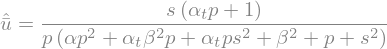

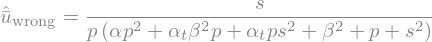

In [3]:
# Eqs. (2)-(3) of C. I. Christov & P. M. Jordan (2009), and Eq. (23) of Tan & Masuoka (2005), in the Laplace domain
t = sp.Symbol('t', real=True)   # not positive=True, otherwise SymPy sets DiracDelta(t) = 0
p = sp.Symbol('p', positive=True)
s, alpha, alpha_t = sp.symbols('s alpha alpha_t', positive=True)
beta = sp.Symbol('beta', nonnegative=True)
w = sp.Function('w')   # Fourier sine transform of u
W, w0, w1 = sp.symbols(r'\hat{\bar{u}} w_0 w_1')
k = s**2 + beta**2

def laplace(expr):
    """Laplace transform in t, with W, w(0), w'(0) as symbols."""
    L = sp.laplace_transform(expr, t, p, noconds=True)
    L = L.subs(sp.LaplaceTransform(w(t), t, p), W)
    L = L.subs(sp.Subs(sp.Derivative(w(t), t), t, 0), w1).subs(w(0), w0)
    return sp.expand(L)

# the Fourier sine transform of d^2u/dy^2 is -s^2 w + s u(0,t), with u(0,t) = H(t)
lhs = w(t).diff(t) + alpha*w(t).diff(t, 2)
rhs_correct = (-k*w(t) + s*sp.Heaviside(t)) + alpha_t*sp.diff(-k*w(t) + s*sp.Heaviside(t), t)
rhs_wrong = (-k*w(t) + s*sp.Heaviside(t)) + alpha_t*sp.diff(-k*w(t), t)   # Eq. (23) of Tan & Masuoka (2005)
W_correct = sp.solve(laplace(lhs - rhs_correct).subs({w0: 0, w1: 0}), W)[0]
W_wrong = sp.solve(laplace(lhs - rhs_wrong).subs({w0: 0, w1: 0}), W)[0]
display(sp.Eq(W, sp.factor(W_correct)))
display(sp.Eq(sp.Symbol(r'\hat{\bar{u}}_\mathrm{wrong}'), sp.factor(W_wrong)))

Inverting Eq. (3) gives $\bar{u}(s,t)=s(s^2+\beta^2)^{-1}-\bar{U}(s,t)$ with, Eq. (4),
$$
\bar{U}(s,t)=s \begin{cases}
\dfrac{\exp[-g(s)t]\{\sqrt{f(s)}\cosh[t\sqrt{f(s)}]+g(s)\sinh[t\sqrt{f(s)}]\}}{\sqrt{f(s)}(s^2+\beta^2)} -\dfrac{\alpha_t\exp[-g(s)t]\sinh[t\sqrt{f(s)}]}{\alpha \sqrt{f(s)}}, &f(s)>0,\\[5mm]
\dfrac{\exp[-g(s)t]\{\sqrt{|f(s)|}\cos[t\sqrt{|f(s)|}]+g(s)\sin[t\sqrt{|f(s)|}]\}}{ \sqrt{|f(s)|}(s^2+\beta^2)} -\dfrac{\alpha_t \exp[-g(s)t]\sin[t\sqrt{|f(s)|}]}{\alpha\sqrt{|f(s)|}}, &f(s)<0,
\end{cases}
$$
and, Eq. (5),
$$
    f(s)=\frac{\alpha_{t}^2(s^2+\beta^2)^2-2(2\alpha-\alpha_t)(s^2+\beta^2)+1}{4\alpha^2},\qquad
    g(s)=\frac{1+\alpha_t(s^2+\beta^2)}{2\alpha}.
$$
For $\beta = 0$, $f$ changes sign at the breakpoints, Eq. (8),
$$
    s_{1,2}^{\bullet}=\alpha_{t}^{-1}\sqrt{2\alpha-\alpha_t\mp 2\sqrt{\alpha(\alpha-\alpha_t)}}\qquad (\alpha_t>0).
$$
The next cell checks with SymPy that the Laplace transform of $s/(s^2+\beta^2) - \bar{U}$ is Eq. (3) (case $f>0$), and solves $f=0$; it should print $0$ and the two breakpoints.

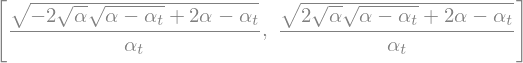

In [4]:
# Eqs. (3)-(5) and (8) of C. I. Christov & P. M. Jordan (2009)
F = sp.Symbol('F', positive=True)   # stands for sqrt(f(s)) > 0
g = (1 + alpha_t*k)/(2*alpha)
f = (alpha_t**2*k**2 - 2*(2*alpha - alpha_t)*k + 1)/(4*alpha**2)
U = s*(sp.exp(-g*t)*(F*sp.cosh(F*t) + g*sp.sinh(F*t))/(F*k) - alpha_t*sp.exp(-g*t)*sp.sinh(F*t)/(alpha*F))
L_U = sp.laplace_transform(U, t, p, noconds=True)
display(sp.simplify((L_U - (s/(k*p) - W_correct)).subs(F, sp.sqrt(f))))
sp.solve(f.subs(beta, 0), s)

Multiplying by $(2/\pi)\sin(sy)$ and integrating gives Eq. (6), $u(y,t)=H(t)\big[\mathrm{e}^{-\beta y}-\frac{2}{\pi}\int_{0}^{\infty}\bar{U}(s,t)\sin(s y)\,\mathrm{d}s\big]$, which for $\beta=0$ and $\alpha>\alpha_t$ is the first case of Eq. (7),
$$
u(y,t)=H(t)\left\{1 -\tfrac{2}{\pi}\left[\int_{0}^{s_{1}^{\bullet}}\bar{\mathcal{U}}_{+}(s,t)\sin(s y)\,\mathrm{d}s + \int_{s_{1}^{\bullet}}^{s_{2}^{\bullet}}\bar{\mathcal{U}}_{-}(s,t)\sin(s y)\,\mathrm{d}s + \int_{s_{2}^{\bullet}}^{\infty}\bar{\mathcal{U}}_{+}(s,t)\sin(s y)\,\mathrm{d}s\right]\right\},
$$
with $\bar{\mathcal{U}}_{\pm}=\bar{U}|_{\beta=0}$ for $f(s)\gtrless 0$. For $\alpha = \alpha_t$, Eq. (7) reduces to $\mathrm{erfc}(\tfrac{1}{2}yt^{-1/2})$. The paper evaluated the integrals with _Mathematica_'s `NIntegrate`; here [`scipy.integrate.quad`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html) is split at $s_1^\bullet$ and $s_2^\bullet$, with a Fourier-weighted rule for the tail.

In [5]:
# Eqs. (4)-(8) of C. I. Christov & P. M. Jordan (2009), beta = 0: correct solution
def Ubar(s, t, alpha, alpha_t):
    """U-bar of Eq. (4) of C. I. Christov & P. M. Jordan (2009) at beta = 0, both signs of f(s) of Eq. (5)."""
    f = (alpha_t**2*s**4 - 2*(2*alpha - alpha_t)*s**2 + 1)/(4*alpha**2)
    g = (1 + alpha_t*s**2)/(2*alpha)
    if f > 0:
        r = np.sqrt(f)
        # exp(-g t) cosh(r t) and exp(-g t) sinh(r t), written so that they do not overflow
        ec = 0.5*(np.exp((r - g)*t) + np.exp(-(r + g)*t))
        es = 0.5*(np.exp((r - g)*t) - np.exp(-(r + g)*t))
        return s*((r*ec + g*es)/(r*s**2) - alpha_t*es/(alpha*r))
    if f < 0:
        r = np.sqrt(-f)
        e = np.exp(-g*t)
        return s*(e*(r*np.cos(t*r) + g*np.sin(t*r))/(r*s**2) - alpha_t*e*np.sin(t*r)/(alpha*r))
    return s*np.exp(-g*t)*((1 + g*t)/s**2 - alpha_t*t/alpha)

def breakpoints(alpha, alpha_t):
    """s_1 and s_2 of Eq. (8) of C. I. Christov & P. M. Jordan (2009), where f(s) changes sign."""
    if alpha_t > 0 and alpha > alpha_t:
        return [np.sqrt(2*alpha - alpha_t - 2*np.sqrt(alpha*(alpha - alpha_t)))/alpha_t,
                np.sqrt(2*alpha - alpha_t + 2*np.sqrt(alpha*(alpha - alpha_t)))/alpha_t]
    return []

def unsteadyv(y, t, alpha, alpha_t):
    """Correct solution, Eq. (7) of C. I. Christov & P. M. Jordan (2009), beta = 0, at one point y > 0."""
    if y == 0:
        return 1.0   # sin(0) = 0, so the formula gives the plate velocity exactly
    edges = [0.0] + breakpoints(alpha, alpha_t)
    if len(edges) == 1:
        edges = [0.0, 1.0]
    total = 0.0
    for i in range(len(edges) - 1):
        total = total + quad(lambda s: Ubar(s, t, alpha, alpha_t)*np.sin(s*y), edges[i], edges[i+1], limit=200)[0]
    total = total + quad(lambda s: Ubar(s, t, alpha, alpha_t), edges[-1], np.inf, weight='sin', wvar=y, limlst=100)[0]
    return 1 - 2/np.pi*total

def profile(func, y, t, alpha, alpha_t):
    """Evaluate a point-wise solution func(y, t, alpha, alpha_t) on an array of y > 0."""
    u = np.zeros_like(y)
    for j in range(len(y)):
        u[j] = func(y[j], t, alpha, alpha_t)
    return u

[pedagogy: one line on why the two terms of $\bar{U}$ cancel as $s\to\infty$ in the correct solution but not in Eq. (32), which is what makes Eq. (32) jump at the wall]

# AN INDEPENDENT CHECK

For $\beta = 0$, the solution in the Laplace domain ([Tanner, 1962](https://doi.org/10.1007/BF01595580)) is Eq. (9) of C. I. Christov & P. M. Jordan (2009),
$$
    \hat{u}(y,p)=\frac{1}{p}\exp \left[-y\sqrt{(1+\alpha p)/(\alpha_t +1/p)}\right].
$$
The next cell checks with SymPy that it solves the Laplace transform of the IBVP, $p(1+\alpha p)\hat{u} = (1+\alpha_t p)\,\frac{\partial^2\hat{u}}{\partial y^2}$ with $\hat{u}(0,p) = 1/p$; it should print two zeros.

In [6]:
# Eq. (9) of C. I. Christov & P. M. Jordan (2009) solves the transformed IBVP (beta = 0)
y = sp.Symbol('y', positive=True)
uhat_sym = sp.exp(-y*sp.sqrt((1 + alpha*p)/(alpha_t + 1/p)))/p
(sp.simplify(p*(1 + alpha*p)*uhat_sym - (1 + alpha_t*p)*uhat_sym.diff(y, 2)), sp.simplify(uhat_sym.subs(y, 0) - 1/p))

Eq. (9) is inverted by Tzou's formula, Eq. (10) of C. I. Christov & P. M. Jordan (2009) (from Tzou (1997)), with $M=10^4$ as in the paper,
$$
\mathfrak{F}(y,t) \approx t^{-1}\mathrm{e}^{4.7}\Big\{\tfrac{1}{2}\hat{\mathfrak{F}}(y,4.7/t) + \mathrm{Re}\Big[\sum_{m=1}^{M}(-1)^{m}\,\hat{\mathfrak{F}}(y,(4.7+\mathrm{i}m\pi)/t)\Big]\Big\},
$$
and, as the more accurate cross-check, by the algorithm of [de Hoog _et al._ (1982)](https://doi.org/10.1137/0903022) in [mpmath's `invertlaplace`](https://mpmath.org/doc/current/calculus/inverselaplace.html).

In [7]:
# Eqs. (9)-(10) of C. I. Christov & P. M. Jordan (2009): numerical inversion of the Laplace transform
def tzou_inverse(Fhat, t, M=10000):
    """Tzou's Riemann-sum inversion of the Laplace transform Fhat(s) at time t."""
    total = 0.5*Fhat(4.7/t).real
    for m in range(1, M+1):
        total = total + ((-1)**m*Fhat((4.7 + 1j*m*np.pi)/t)).real
    return np.exp(4.7)/t*total

def uhat(y, p, alpha, alpha_t):
    """Eq. (9) of C. I. Christov & P. M. Jordan (2009), beta = 0."""
    return np.exp(-y*np.sqrt((1 + alpha*p)/(alpha_t + 1/p)))/p

def uhat_mp(p, y, alpha, alpha_t):
    """Eq. (9) of C. I. Christov & P. M. Jordan (2009) in mpmath arithmetic."""
    return mp.exp(-y*mp.sqrt((1 + alpha*p)/(alpha_t + 1/p)))/p

def dehoog_inverse(y, t, alpha, alpha_t):
    """Eq. (9) of C. I. Christov & P. M. Jordan (2009) inverted by mpmath's de Hoog algorithm, point by point in y."""
    # preferred over tzou_inverse: about 10 correct digits, while Tzou's formula
    # cannot do better than about exp(-9.4) = 8e-5, however large M is
    u = np.zeros_like(y)
    for j in range(len(y)):
        u[j] = float(mp.invertlaplace(lambda p: uhat_mp(p, y[j], alpha, alpha_t), t, method='dehoog'))
    return u

The finite-difference check uses `startup_fd`, written for $(1+\partial_{t_\mathrm{fd}})\,\mathrm{Re}\,\partial_{t_\mathrm{fd}} v = (1+\kappa\partial_{t_\mathrm{fd}})\,\frac{\partial^2 v}{\partial x^2}$ in polymer-stress form ($S = \sigma - \kappa\,\frac{\partial v}{\partial x}$),
\begin{align*}
    \mathrm{Re}\,\frac{\partial v}{\partial t_\mathrm{fd}} &= \frac{\partial S}{\partial x} + \kappa\frac{\partial^2 v}{\partial x^2},\qquad
    \frac{\partial S}{\partial t_\mathrm{fd}} + S = (1-\kappa)\,\frac{\partial v}{\partial x},
\end{align*}
with Crank&ndash;Nicolson (Rannacher start-up) for the diffusion and the trapezoidal rule for $S$. For $\beta = 0$ the IBVP maps onto it with $t_\mathrm{fd} = t/\alpha$, $\mathrm{Re} = 1/\alpha$, $\kappa = \alpha_t/\alpha$ and $y = L - x$, the moving plate at $x = L$; $L = 2$ is far enough for the disturbance not to reach $x=0$ by $t = 0.05$.

In [8]:
# Finite differences for Eq. (1) of C. I. Christov & P. M. Jordan (2009), beta = 0: startup_fd
def startup_fd(M=400, kappa=0.5, Re=1.0, tmax=1.0, L=1.0, dt=None, n_rannacher=4, n_iter=3):
    """Start-up plane Couette flow of a Jeffreys fluid, (v, S) form; time scaled by lambda_1, plate at x = L."""
    dx = L/M
    if dt is None:
        dt = 0.5*dx*min(1.0, np.sqrt(Re))
    nsteps = int(np.ceil(tmax/dt))
    dt = tmax/nsteps
    x = np.linspace(0, L, M+1)
    v = np.zeros(M+1)
    S = np.zeros(M)
    v[-1] = 1.0
    # tridiagonal matrices for Crank-Nicolson (theta = 1/2) and backward Euler (theta = 1)
    r_cn = 0.5*kappa*dt/(Re*dx**2)
    ab_cn = np.zeros((3, M-1))
    ab_cn[0, 1:] = -r_cn
    ab_cn[1, :] = 1 + 2*r_cn
    ab_cn[2, :-1] = -r_cn
    r_be = kappa*dt/(Re*dx**2)
    ab_be = np.zeros((3, M-1))
    ab_be[0, 1:] = -r_be
    ab_be[1, :] = 1 + 2*r_be
    ab_be[2, :-1] = -r_be
    for n in range(nsteps):
        g = np.diff(v)/dx
        dS = -S + (1 - kappa)*g
        Sp = S + dt*dS
        if n < n_rannacher:
            r = r_be
            ab = ab_be
        else:
            r = r_cn
            ab = ab_cn
        vb = v.copy()
        # iterate the trapezoidal stress update and the implicit velocity update a few times
        for it in range(n_iter):
            Sm = 0.5*(S + Sp)
            rhs = v[1:-1] + dt/Re*np.diff(Sm)/dx
            if n >= n_rannacher:
                rhs = rhs + r*(v[2:] - 2*v[1:-1] + v[:-2])
            rhs[0] = rhs[0] + r*vb[0]
            rhs[-1] = rhs[-1] + r*vb[-1]
            vb[1:-1] = solve_banded((1, 1), ab, rhs)
            gp = np.diff(vb)/dx
            Sp = S + 0.5*dt*(dS + (-Sp + (1 - kappa)*gp))
        S = Sp
        v = vb
    return x, v

def fd_profile(t, alpha, alpha_t, M=800, L=2.0):
    """u(y,t) from startup_fd, mapped back to y = L - x."""
    x, v = startup_fd(M=M, kappa=alpha_t/alpha, Re=1/alpha, tmax=t/alpha, L=L)
    return L - x, v

The next cell prints the checks:

* limits: for $\alpha = \alpha_t$, Eq. (7) against $\mathrm{erfc}(\tfrac{1}{2}yt^{-1/2})$; for $\alpha_t = 0$ (Maxwell fluid), where Eqs. (32) and (7) coincide, both against de Hoog's inversion of Eq. (9) (all at round-off or quadrature level);
* the breakpoints of Eq. (8) against $a$ and $b$ of Tan & Masuoka (2005), which should be equal;
* Eq. (7) against de Hoog's inversion (about $10^{-10}$), Tzou's inversion (below $10^{-4}$) and finite differences; the size of the error of Eq. (32); and the value of Eq. (32) at the wall, which should be $1-\mathrm{e}^{-t/\alpha_t}$ instead of 1;
* convergence tables for Tzou's $M$ and the finite-difference grid (first order: the initial and boundary data are incompatible at $(y,t)=(0,0)$).

In [9]:
# Checks for C. I. Christov & P. M. Jordan (2009)
alpha, alpha_t, t = 0.15, 0.1, 0.05
y = np.linspace(0.02, 0.8, 40)

print('LIMITS (should be at round-off level)')
y_limit = np.array([0.05, 0.1, 0.2, 0.4])
print(f'  alpha = alpha_t = 0.1: max|Eq. (7) - erfc| = {np.abs(profile(unsteadyv, y_limit, t, 0.1, 0.1) - erfc(y_limit/(2*np.sqrt(t)))).max():.1e}')
y_behind = np.array([0.02, 0.05, 0.1])   # behind the elastic front at y = t/sqrt(alpha) = 0.13
u_maxwell = dehoog_inverse(y_behind, t, alpha, 0.0)
print(f'  alpha_t = 0: max|Eq. (32) - de Hoog| = {np.abs(profile(wrong_tan_masuoka_32, y_behind, t, alpha, 0.0) - u_maxwell).max():.1e}, '
      f'max|Eq. (7) - de Hoog| = {np.abs(profile(unsteadyv, y_behind, t, alpha, 0.0) - u_maxwell).max():.1e}')

print('\nBREAKPOINTS')
print(f'  Eq. (8): s1 = {breakpoints(alpha, alpha_t)[0]:.12f}, s2 = {breakpoints(alpha, alpha_t)[1]:.12f}')
print(f'  Tan & Masuoka: a = {1/(np.sqrt(alpha) + np.sqrt(alpha - alpha_t)):.12f}, b = {1/(np.sqrt(alpha) - np.sqrt(alpha - alpha_t)):.12f}')

print(f'\nEQ. (7) VERSUS INDEPENDENT SOLUTIONS, alpha = {alpha}, alpha_t = {alpha_t}, t = {t}, max over 0.02 <= y <= 0.8')
u_correct = profile(unsteadyv, y, t, alpha, alpha_t)
u_dehoog = dehoog_inverse(y, t, alpha, alpha_t)
u_tzou = tzou_inverse(lambda p: uhat(y, p, alpha, alpha_t), t, 10000)
yf, uf = fd_profile(t, alpha, alpha_t, 800)
u_fd = np.interp(y, yf[::-1], uf[::-1])
u_wrong = profile(wrong_tan_masuoka_32, y, t, alpha, alpha_t)
print(f'  de Hoog: {np.abs(u_correct - u_dehoog).max():.1e}')
print(f'  Tzou, M = 10^4: {np.abs(u_correct - u_tzou).max():.1e}')
print(f'  finite differences, M = 800: {np.abs(u_correct - u_fd).max():.1e}')
print(f'  wrong Eq. (32) - Eq. (7): {np.abs(u_wrong - u_correct).max():.2f}')
print(f'  at y = 1e-4: Eq. (32) = {wrong_tan_masuoka_32(1e-4, t, alpha, alpha_t):.4f}, 1 - exp(-t/alpha_t) = {1 - np.exp(-t/alpha_t):.4f}, Eq. (7) = {unsteadyv(1e-4, t, alpha, alpha_t):.4f}')

print('\nCONVERGENCE OF TZOU\'S INVERSION IN M (floor about 8e-5)')
for M in [100, 1000, 10000]:
    print(f'  M = {M:5d}: {np.abs(tzou_inverse(lambda p: uhat(y, p, alpha, alpha_t), t, M) - u_dehoog).max():.1e}')

print('\nCONVERGENCE OF THE FINITE DIFFERENCES (dt refined with dx), max error and observed order')
previous = None
for M in [200, 400, 800, 1600]:
    yf, uf = fd_profile(t, alpha, alpha_t, M)
    error = np.abs(np.interp(y, yf[::-1], uf[::-1]) - u_dehoog).max()
    if previous is None:
        print(f'  M = {M:4d}: {error:.1e}')
    else:
        print(f'  M = {M:4d}: {error:.1e} ({np.log2(previous/error):.2f})')
    previous = error

LIMITS (should be at round-off level)
  alpha = alpha_t = 0.1: max|Eq. (7) - erfc| = 1.1e-16
  alpha_t = 0: max|Eq. (32) - de Hoog| = 2.4e-10, max|Eq. (7) - de Hoog| = 2.4e-10

BREAKPOINTS
  Eq. (8): s1 = 1.636915368708, s2 = 6.109051323707
  Tan & Masuoka: a = 1.636915368708, b = 6.109051323707

EQ. (7) VERSUS INDEPENDENT SOLUTIONS, alpha = 0.15, alpha_t = 0.1, t = 0.05, max over 0.02 <= y <= 0.8


  de Hoog: 1.7e-10
  Tzou, M = 10^4: 8.0e-05
  finite differences, M = 800: 9.4e-05
  wrong Eq. (32) - Eq. (7): 0.59
  at y = 1e-4: Eq. (32) = 0.3933, 1 - exp(-t/alpha_t) = 0.3935, Eq. (7) = 0.9997

CONVERGENCE OF TZOU'S INVERSION IN M (floor about 8e-5)
  M =   100: 4.2e-02
  M =  1000: 2.9e-04
  M = 10000: 8.0e-05

CONVERGENCE OF THE FINITE DIFFERENCES (dt refined with dx), max error and observed order
  M =  200: 5.4e-04
  M =  400: 2.4e-04 (1.21)
  M =  800: 9.4e-05 (1.33)
  M = 1600: 3.2e-05 (1.53)


This is Fig. 1 of C. I. Christov & P. M. Jordan (2009): $u$ versus $y$ for $\beta=0$, $\alpha=0.15$, $\alpha_t=0.1$ and $t = 0.05$, with Eq. (32) of Tan & Masuoka (2005) broken, Eq. (7) dotted, and the inverse of Eq. (9) by Eq. (10) with $M=10^4$ solid.

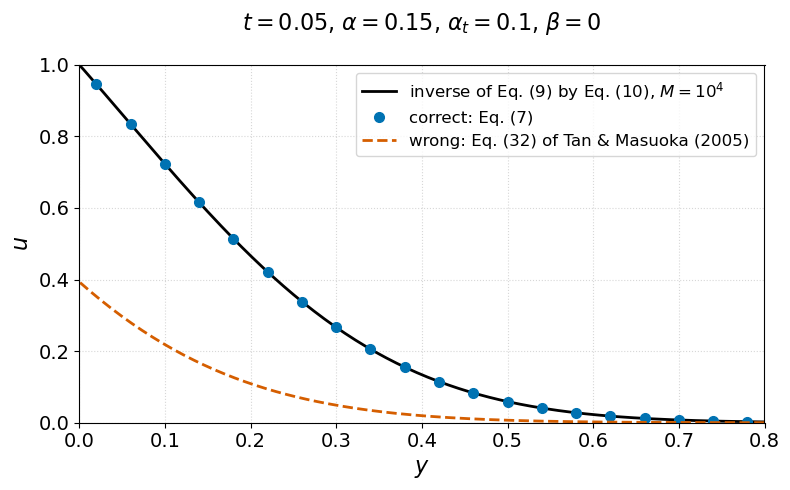

In [10]:
# Fig. 1 of C. I. Christov & P. M. Jordan (2009)
alpha, alpha_t, t = 0.15, 0.1, 0.05
y = np.linspace(1e-3, 0.8, 200)
y_dots = np.linspace(0.02, 0.78, 20)

fig, ax = plt.subplots(figsize=(8, 5), tight_layout=True)
ax.plot(y, tzou_inverse(lambda p: uhat(y, p, alpha, alpha_t), t, 10000), color='black', linewidth=2,
        label='inverse of Eq. (9) by Eq. (10), $M=10^4$')
ax.plot(y_dots, profile(unsteadyv, y_dots, t, alpha, alpha_t), 'o', color='#0072B2', markersize=7,
        label='correct: Eq. (7)')
ax.plot(y, profile(wrong_tan_masuoka_32, y, t, alpha, alpha_t), color='#D55E00', linewidth=2, linestyle='dashed',
        label='wrong: Eq. (32) of Tan & Masuoka (2005)')
ax.set_xlabel('$y$')
ax.set_ylabel('$u$')
ax.set_xlim(0, 0.8)
ax.set_ylim(0, 1)
ax.set_title(rf'$t = {t}$, $\alpha = {alpha}$, $\alpha_t = {alpha_t}$, $\beta = 0$')
ax.grid(alpha=0.5, linestyle='dotted')
ax.legend(loc='upper right', fontsize=12)
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/christov_jordan_2009_fig1.png', dpi=200, bbox_inches='tight')

[pedagogy: one line on the jump of Eq. (32) at $y=0^+$ and why a correct solution cannot have it]

In [11]:
# Eq. (7) of C. I. Christov & P. M. Jordan (2009) and Eq. (32) of Tan & Masuoka (2005): interactive comparison
def plot_func(alpha, alpha_t, t):
    y = np.linspace(0, 1, 101)   # fine grid for the envelope
    y_arrows = np.linspace(0, 1, 16)   # about 15 arrows, one at the wall
    u = profile(unsteadyv, y, t, alpha, alpha_t)
    u_wrong = profile(wrong_tan_masuoka_32, y, t, alpha, alpha_t)

    fig, ax = plt.subplots(tight_layout=True)
    ax.set_ylabel('$y$')
    ax.set_ylim(0, 1)
    ax.set_xlabel('$u$')
    ax.set_xlim(0, 1.1)
    ax.plot(u, y, color='darkblue', linewidth=4, label=f'correct, $t={t:.3f}$')
    ax.quiver(0*y_arrows, y_arrows, np.interp(y_arrows, y, u), 0*y_arrows, scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
    ax.plot(u_wrong, y, color='#D55E00', linewidth=2, linestyle='dashed', label='wrong: Eq. (32)')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.5, linestyle='dotted')
    plt.show()

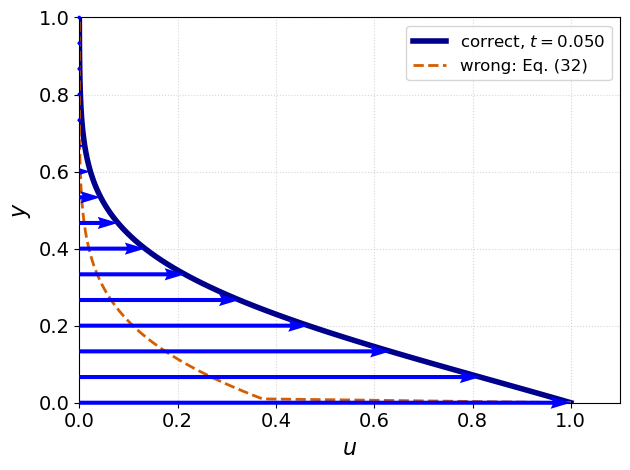

In [12]:
# Eq. (7) of C. I. Christov & P. M. Jordan (2009) and Eq. (32) of Tan & Masuoka (2005): static plot (the interactive widget below is stripped in the GitHub preview)
plot_func(0.15, 0.1, 0.05)

In [13]:
# Eq. (7) of C. I. Christov & P. M. Jordan (2009) and Eq. (32) of Tan & Masuoka (2005): interactive plot
interact(plot_func,
         alpha=widgets.FloatSlider(value=0.15, min=0.02, max=0.5, step=0.01, description='Relax., alpha'),
         alpha_t=widgets.FloatSlider(value=0.1, min=0.0, max=0.5, step=0.01, description='Retard., alpha_t'),
         t=widgets.FloatSlider(value=0.05, min=0.005, max=0.3, step=0.005, readout_format='.3f', description='Time, t'));

In [14]:
# Eq. (7) of C. I. Christov & P. M. Jordan (2009) and Eq. (32) of Tan & Masuoka (2005): animation
alpha, alpha_t = 0.15, 0.1
y = np.linspace(0, 1, 101)   # fine grid for the envelope
y_arrows = np.linspace(0, 1, 16)   # about 15 arrows, one at the wall
u = profile(unsteadyv, y, 0.005, alpha, alpha_t)

fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel('$y$')
ax.set_ylim(0, 1)
ax.set_xlabel('$u$')
ax.set_xlim(0, 1.1)
ax.grid(alpha=0.5, linestyle='dotted')
plt.close()

line, = ax.plot(u, y, color='darkblue', linewidth=4, label='correct')
line_wrong, = ax.plot(profile(wrong_tan_masuoka_32, y, 0.005, alpha, alpha_t), y, color='#D55E00',
                      linewidth=2, linestyle='dashed', label='wrong: Eq. (32)')
quiv = ax.quiver(0*y_arrows, y_arrows, np.interp(y_arrows, y, u), 0*y_arrows, scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
ax.legend(loc='upper right')

# number of animation frames
numframes = 50
tmax = 0.25

# animation function called sequentially by `FuncAnimation' below
def animate(i):
    # the i passed is the frame counter, rescaled to get the time
    tstar = (i + 1)/numframes*tmax
    u = profile(unsteadyv, y, tstar, alpha, alpha_t)
    line.set_data(u, y)
    line_wrong.set_data(profile(wrong_tan_masuoka_32, y, tstar, alpha, alpha_t), y)
    quiv.set_UVC(np.interp(y_arrows, y, u), 0*y_arrows)
    line.set_label(f'correct, $t={tstar:.3f}$')
    legend = ax.legend(loc='upper right')
    return (line, line_wrong, quiv, legend)

anim = animation.FuncAnimation(fig, animate, frames=numframes, interval=150, blit=True, repeat=False)

In [15]:
# this is necessary to get the animation to work on Google's Colab
rc('animation', html='jshtml')
anim

In [16]:
# To save the animation, use something like
# anim.save('christov_jordan_2009_startup.mp4')

# WHAT PROBLEM DOES THE WRONG SOLUTION ACTUALLY SOLVE?

The transform of the wrong subsidiary equation is Eq. (3) divided by $1+\alpha_t p$. So Eq. (32) of Tan & Masuoka (2005) solves the IBVP (1) with the plate ramped on the retardation time instead of started impulsively,
$$
    u(0,t) = \left(1 - \mathrm{e}^{-t/\alpha_t}\right)H(t),\qquad \hat{u}_\mathrm{wrong}(y,p) = \frac{\hat{u}(y,p)}{1+\alpha_t p}.
$$
This identification is shown here; it is not stated in C. I. Christov & P. M. Jordan (2009). The next cell should print $1/(\alpha_t p + 1)$.

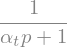

In [17]:
# Eq. (3) of C. I. Christov & P. M. Jordan (2009) and Eq. (23) of Tan & Masuoka (2005): ratio of the transforms
sp.simplify(W_wrong/W_correct)

The next cell compares Eq. (32) with the de Hoog inversion of $\hat{u}(y,p)/(1+\alpha_t p)$; the difference should be at the level of the quadrature tolerance.

In [18]:
# Eq. (32) of Tan & Masuoka (2005) versus the ramped-plate solution, inverse of Eq. (9)/(1 + alpha_t p)
alpha, alpha_t, t = 0.15, 0.1, 0.05
y = np.linspace(0.02, 0.8, 40)
u_ramp = np.zeros_like(y)
for j in range(len(y)):
    u_ramp[j] = float(mp.invertlaplace(lambda p: uhat_mp(p, y[j], alpha, alpha_t)/(1 + alpha_t*p), t, method='dehoog'))
print(f'max|Eq. (32) - ramped-plate solution| = {np.abs(profile(wrong_tan_masuoka_32, y, t, alpha, alpha_t) - u_ramp).max():.1e}')

max|Eq. (32) - ramped-plate solution| = 2.6e-10


# ON YOUR OWN

On your own:

*   Set $\alpha_t = 0$ in the interactive plot and explain, from Eq. (2), why Eq. (32) is then correct.
*   Compare Eq. (32) and Eq. (7) at a fixed $y$ as functions of $t$, and find when the error drops below 1%.
*   Choose $\alpha < \alpha_t$ (no breakpoints, last case of Eq. (7)) and repeat the checks.

# REFERENCES

C. I. Christov, P. M. Jordan, Comment on &ldquo;Stokes' first problem for an Oldroyd-B fluid in a porous half space&rdquo; [Phys. Fluids 17, 023101 (2005)], _Phys. Fluids_ **21** (2009) 069101. [doi:10.1063/1.3126503](https://doi.org/10.1063/1.3126503)

F. R. de Hoog, J. H. Knight, A. N. Stokes, An improved method for numerical inversion of Laplace transforms, _SIAM J. Sci. Stat. Comput._ **3** (1982) 357&ndash;366. [doi:10.1137/0903022](https://doi.org/10.1137/0903022)

C. R. Harris, K. J. Millman, S. J. van der Walt, _et al._, Array programming with NumPy, _Nature_ **585** (2020) 357&ndash;362. [doi:10.1038/s41586-020-2649-2](https://doi.org/10.1038/s41586-020-2649-2)

J. D. Hunter, Matplotlib: A 2D graphics environment, _Comput. Sci. Eng._ **9** (2007) 90&ndash;95. [doi:10.1109/MCSE.2007.55](https://doi.org/10.1109/MCSE.2007.55)

A. Meurer, C. P. Smith, M. Paprocki, _et al._, SymPy: symbolic computing in Python, _PeerJ Comput. Sci._ **3** (2017) e103. [doi:10.7717/peerj-cs.103](https://doi.org/10.7717/peerj-cs.103)

The mpmath development team, _mpmath: a Python library for arbitrary-precision floating-point arithmetic_ (version 1.3.0), 2023. [mpmath.org](https://mpmath.org/)

R. I. Tanner, Note on the Rayleigh problem for a visco-elastic fluid, _Z. Angew. Math. Phys._ **13** (1962) 573&ndash;580. [doi:10.1007/BF01595580](https://doi.org/10.1007/BF01595580)

D. Y. Tzou, _Macro- to Microscale Heat Transfer: The Lagging Behavior_, Taylor & Francis, Washington, DC, 1997.

P. Virtanen, R. Gommers, T. E. Oliphant, _et al._, SciPy 1.0: fundamental algorithms for scientific computing in Python, _Nat. Methods_ **17** (2020) 261&ndash;272. [doi:10.1038/s41592-019-0686-2](https://doi.org/10.1038/s41592-019-0686-2)